# What are the most demanded skills for the top 3 most popular data roles? 

## Methodology
1. Clean-up skill column
2. Calculate skill  count based on job_title_short
3. Calculate skill percentage 
4. Plot final findings

## Imports and loading data 

In [2]:
import pandas as pd
import ast 
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
# load dataset using load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()



## clean-up dataframe 

In [3]:
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda job: ast.literal_eval(job) if pd.notna(job) else job)

## 2.Calculate skill count based on job_title-short

In [4]:
# filltering for US
df_US=df[df['job_country']=='United States']


In [5]:
# exploding job skills list object
df_US_exploded=df_US.explode('job_skills').copy()

In [6]:
df_skill_count=df_US_exploded.groupby(['job_skills', 'job_title_short']).size().reset_index(name='skill_count').sort_values(by='skill_count', ascending=False)
df_skill_count.head(4)

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519


In [7]:
job_titles=df_skill_count['job_title_short'].unique().tolist()
top_titles= job_titles[:3]
top_titles.sort()
top_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

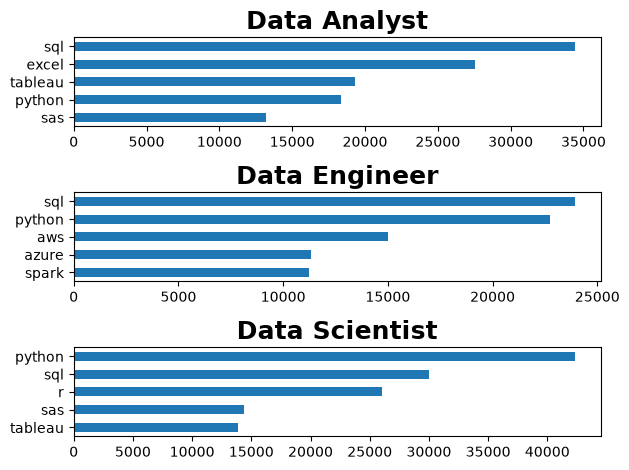

In [8]:
fig, ax=plt.subplots(len(top_titles), 1)

for index, job_title in enumerate(top_titles):
    df_plot=df_skill_count[df_skill_count['job_title_short']==job_title].head(5).sort_values(by='skill_count')
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[index])   
    ax[index].legend().set_visible(False)
    ax[index].set_ylabel("")
    ax[index].set_title(job_title, weight='bold', fontsize=18)
    
plt.tight_layout()


plt.show()

## 3.Calculate percentages

In [9]:
df_job_title_count=df_US['job_title_short'].value_counts().reset_index(name='total_jobs')
df_job_title_count

,job_title_short,total_jobs
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [10]:
df_skills_prc=pd.merge(df_skill_count, df_job_title_count, how='left', on='job_title_short')
df_skills_prc.head()

,job_skills,job_title_short,skill_count,total_jobs
0,python,Data Scientist,42379,58830
1,sql,Data Analyst,34452,67816
2,sql,Data Scientist,30034,58830
3,excel,Data Analyst,27519,67816
4,r,Data Scientist,26022,58830


In [11]:
df_skills_prc['skill_percentage']= df_skills_prc['skill_count'] / df_skills_prc['total_jobs'] *100
df_skills_prc

,job_skills,job_title_short,skill_count,total_jobs,skill_percentage
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


## 4.Final Plot

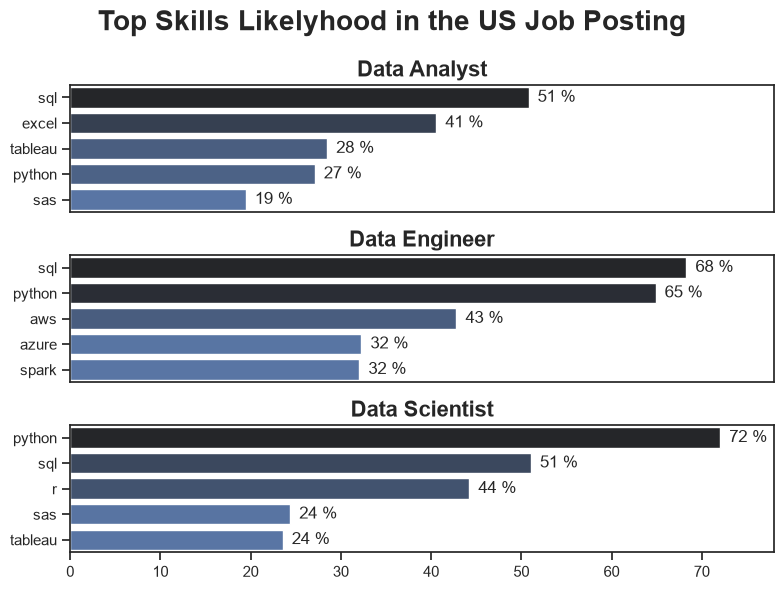

In [26]:
fig, ax=plt.subplots(len(top_titles), 1, figsize=(8,6))

sns.set_theme(style='ticks')
for index, job_title in enumerate(top_titles):
    df_plot=df_skills_prc[df_skills_prc['job_title_short']==job_title].head(5)
    #df_plot.plot(kind='barh', x='job_skills', y='skill_percentage', ax=ax[index]) 
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills',ax=ax[index], hue='skill_count',palette='dark:b_r')
    ax[index].legend().set_visible(False)
    ax[index].set_ylabel("")
    ax[index].set_xlabel("")
    ax[index].set_title(job_title, weight='bold', fontsize=16)
    ax[index].set_xlim(0,78)
    
    for n,v in enumerate(df_plot['skill_percentage']):
        ax[index].text(v+1,n , f'{v:.0f} %', va='center')
    if index!=2:
     ax[index].set_xticks([])

fig.suptitle("Top Skills Likelyhood in the US Job Posting", weight='bold', fontsize=20)
plt.tight_layout()
plt.show()